<a href="https://colab.research.google.com/github/loki-gif/case_study/blob/main/HR_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hr = pd.read_csv('/content/train_LZdllcl.csv')
hr.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [10]:
hr.duplicated().sum()

np.int64(0)

In [11]:
hr = hr.drop(columns = ['employee_id'])

In [12]:
hr.isnull().sum()

,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0
KPIs_met >80%,0


In [15]:
(hr.isnull().sum() / len(hr)) * 100

,0
department,0.000000
region,0.000000
education,4.395344
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000
KPIs_met >80%,0.000000


In [16]:
hr['education'] = hr['education'].fillna(hr['education'].mode()[0])

In [17]:
hr['previous_year_rating'] = hr['previous_year_rating'].fillna(hr['previous_year_rating'].mode()[0])

In [19]:
hr['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [20]:
hr['is_promoted'].value_counts(normalize=True)*100

,proportion
is_promoted,
0,91.482995
1,8.517005


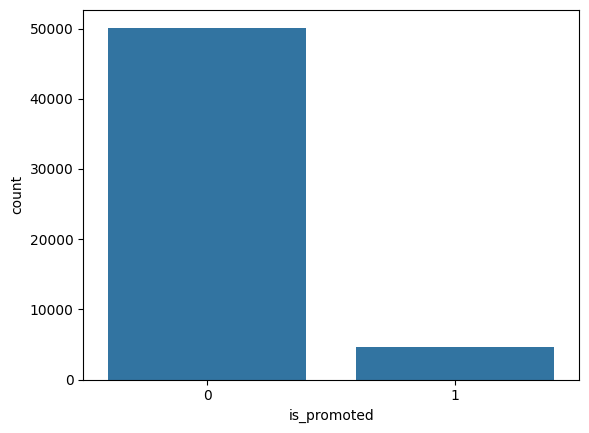

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x = 'is_promoted',data = hr)
plt.show()

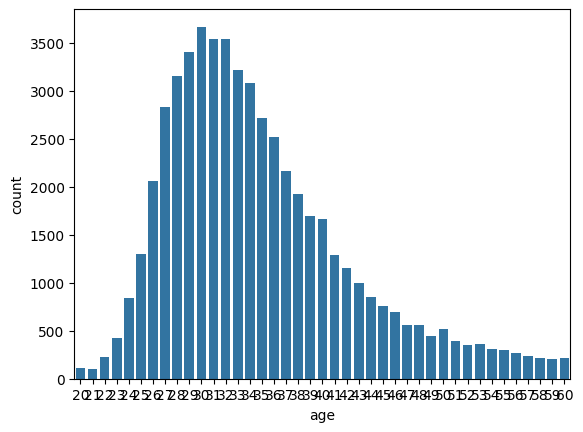

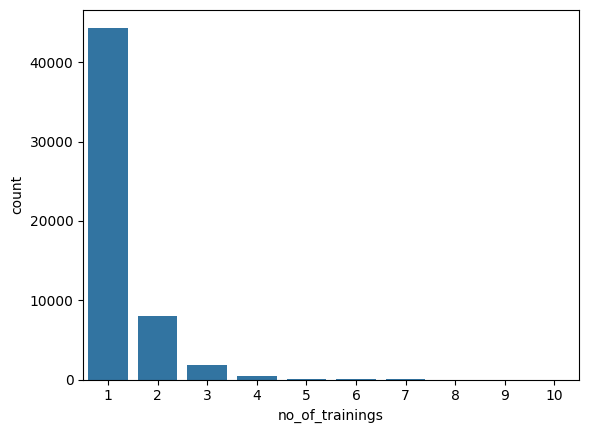

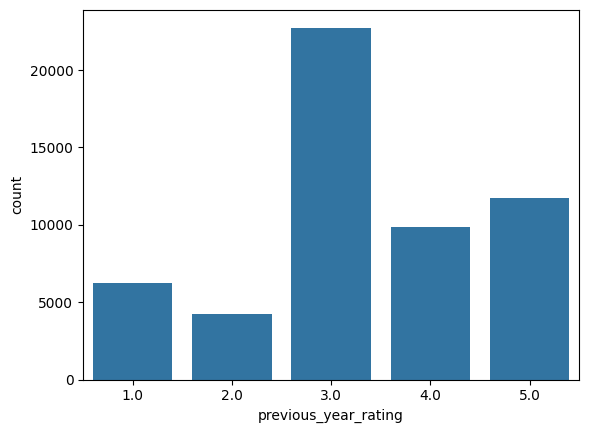

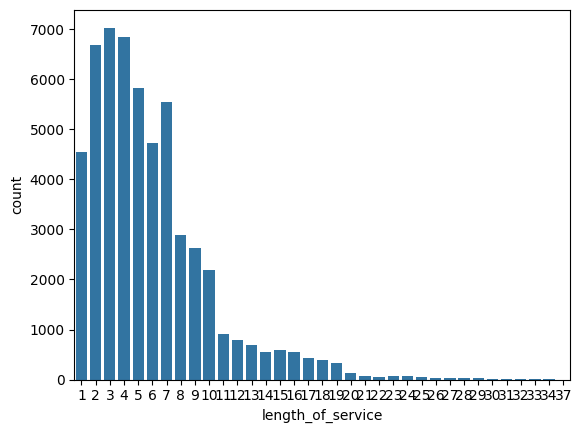

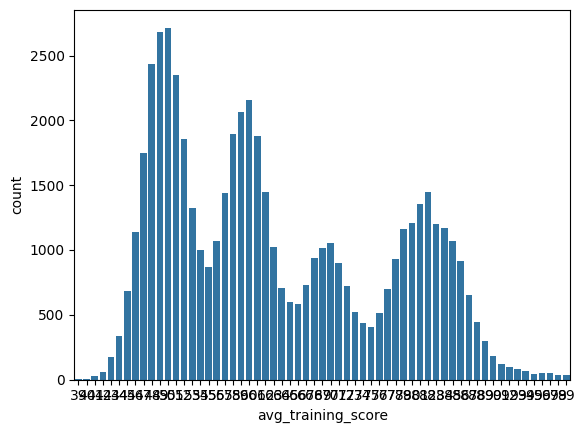

In [28]:
num_cols = ['age','no_of_trainings','previous_year_rating','length_of_service','avg_training_score']
for i in num_cols :
  sns.countplot(x = i, data = hr)
  plt.show()

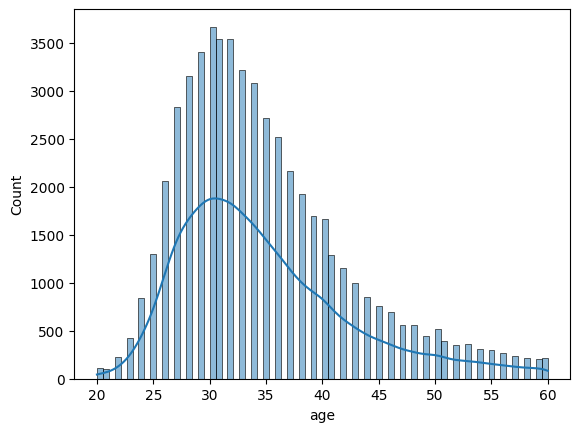

In [25]:
sns.histplot(hr['age'], kde=True)
plt.show()

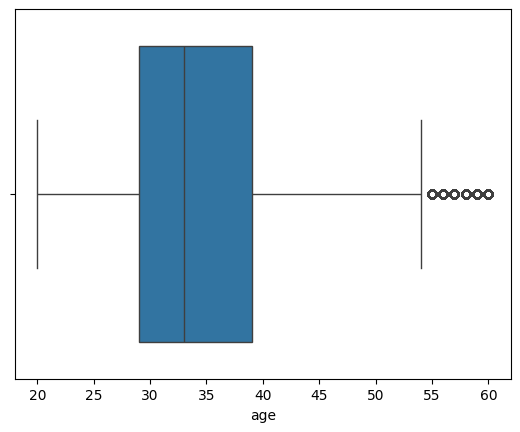

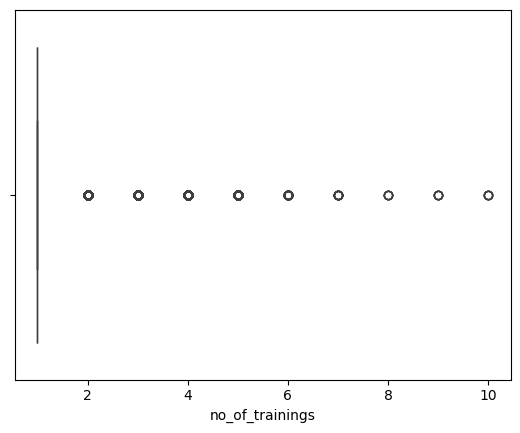

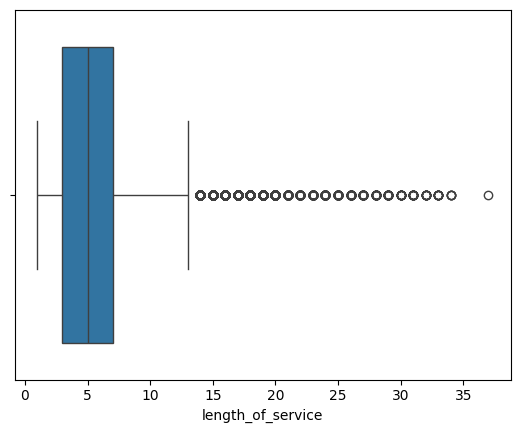

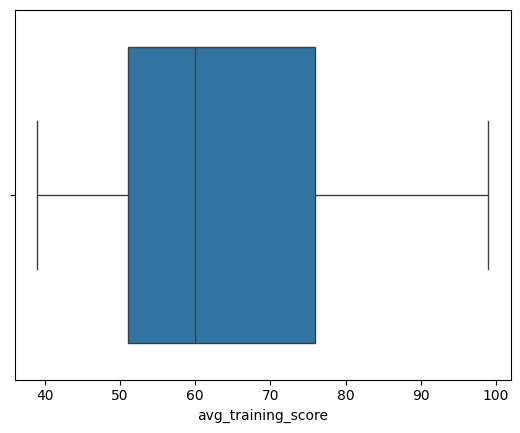

In [31]:
num_col = ['age','no_of_trainings','length_of_service','avg_training_score']
for i in num_col :
  sns.boxplot(x = i, data = hr)
  plt.show()

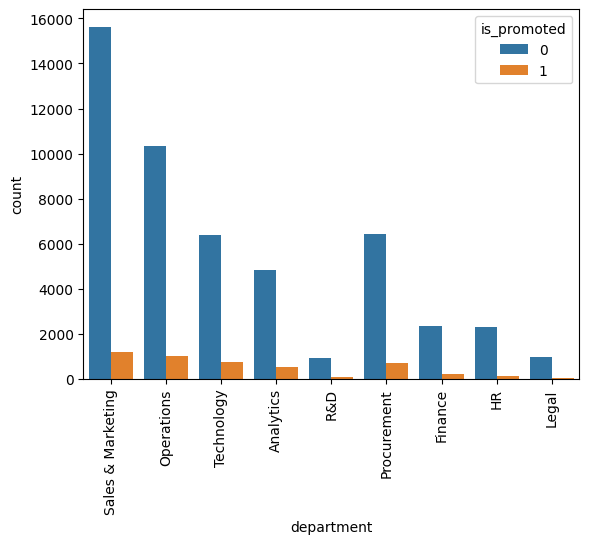

In [30]:
sns.countplot(x='department', hue='is_promoted', data=hr)
plt.xticks(rotation=90)
plt.show()

In [35]:
m_cols = ['age','length_of_service','avg_training_score']
for i in m_cols :
  Q1 = hr[i].quantile(0.25)
  Q3 = hr[i].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  outliers = hr[(hr[i] < lower) | (hr[i] > upper)]

  print(i,':')
  print(f"lower limit : {lower}")
  print(f"upper limit : {upper}")
  print(f"outliers : {len(outliers)}")

age :
lower limit : 14.0
upper limit : 54.0
outliers : 1435
length_of_service :
lower limit : -3.0
upper limit : 13.0
outliers : 3489
avg_training_score :
lower limit : 13.5
upper limit : 113.5
outliers : 0


In [40]:
hr['age'].value_counts()

,count
age,
30,3665
32,3534
31,3534
29,3405
33,3210
28,3147
34,3076
27,2827
35,2711


In [41]:
hr['length_of_service'].value_counts()

,count
length_of_service,
3,7033
4,6836
2,6684
5,5832
7,5551
6,4734
1,4547
8,2883
9,2629


In [42]:
hr['department'].value_counts()

,count
department,
Sales & Marketing,16840
Operations,11348
Technology,7138
Procurement,7138
Analytics,5352
Finance,2536
HR,2418
Legal,1039
R&D,999


In [44]:
hr['region'].value_counts()

,count
region,
region_2,12343
region_22,6428
region_7,4843
region_15,2808
region_13,2648
region_26,2260
region_31,1935
region_4,1703
region_27,1659


In [45]:
hr['education'].value_counts()

,count
education,
Bachelor's,39078
Master's & above,14925
Below Secondary,805


In [46]:
hr['recruitment_channel'].value_counts()

,count
recruitment_channel,
other,30446
sourcing,23220
referred,1142


In [47]:
education_map = {
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}

hr['education'] = hr['education'].map(education_map)

In [48]:
gender_map = {
    'm': 0,
    'f': 1
}

hr['gender'] = hr['gender'].map(gender_map)

In [49]:
hr = pd.get_dummies(
    hr,
    columns=['department', 'region', 'recruitment_channel'],
    drop_first=True,
    dtype=int
)

In [50]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   education                     54808 non-null  int64  
 1   gender                        54808 non-null  int64  
 2   no_of_trainings               54808 non-null  int64  
 3   age                           54808 non-null  int64  
 4   previous_year_rating          54808 non-null  float64
 5   length_of_service             54808 non-null  int64  
 6   KPIs_met >80%                 54808 non-null  int64  
 7   awards_won?                   54808 non-null  int64  
 8   avg_training_score            54808 non-null  int64  
 9   is_promoted                   54808 non-null  int64  
 10  department_Finance            54808 non-null  int64  
 11  department_HR                 54808 non-null  int64  
 12  department_Legal              54808 non-null  int64  
 13  d

In [51]:
hr.head()

,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,...,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,recruitment_channel_referred,recruitment_channel_sourcing
0,2,1,1,35,5.0,8,1,0,49,0,...,0,0,0,0,0,1,0,0,0,1
1,1,0,1,30,5.0,4,0,0,60,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,34,3.0,7,0,0,50,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,2,39,1.0,10,0,0,50,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,45,3.0,2,0,0,73,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
X = hr.drop(['is_promoted'], axis=1)

y = hr['is_promoted']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)

In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_valid_scaled)

In [67]:
from sklearn.metrics import f1_score
f1 = f1_score(y_valid, y_pred)

print("F1 Score:", f1)

F1 Score: 0.40865384615384615


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_valid)

print("Decision Tree F1 Score:", f1_score(y_valid, y_pred_dt))

Decision Tree F1 Score: 0.42051802945657696


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

print("Random Forest F1 Score:", f1_score(y_valid, y_pred_rf))

Random Forest F1 Score: 0.41620333598093723


In [60]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "F1 Score": [
        f1_score(y_valid, y_pred),
        f1_score(y_valid, y_pred_dt),
        f1_score(y_valid, y_pred_rf)
    ]
}

import pandas as pd

pd.DataFrame(results)

,Model,F1 Score
0,Logistic Regression,0.408654
1,Decision Tree,0.420518
2,Random Forest,0.416203


In [62]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_valid)

print("CatBoost F1 Score:", f1_score(y_valid, y_pred_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
CatBoost F1 Score: 0.5165257494235204


In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_valid)

print("XGBoost F1 Score:", f1_score(y_valid, y_pred_xgb))

XGBoost F1 Score: 0.5202754399387911


In [64]:
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_valid)

print("LightGBM F1 Score:", f1_score(y_valid, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3734, number of negative: 40112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 43846, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085162 -> initscore=-2.374195
[LightGBM] [Info] Start training from score -2.374195
LightGBM F1 Score: 0.515625


In [68]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],
    'Accuracy': [
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_xgb),
        accuracy_score(y_valid, y_pred_lgb),
        accuracy_score(y_valid, y_pred_cat)
    ],
    'Precision': [
        precision_score(y_valid, y_pred_lr),
        precision_score(y_valid, y_pred_dt),
        precision_score(y_valid, y_pred_rf),
        precision_score(y_valid, y_pred_xgb),
        precision_score(y_valid, y_pred_lgb),
        precision_score(y_valid, y_pred_cat)
    ],
    'Recall': [
        recall_score(y_valid, y_pred_lr),
        recall_score(y_valid, y_pred_dt),
        recall_score(y_valid, y_pred_rf),
        recall_score(y_valid, y_pred_xgb),
        recall_score(y_valid, y_pred_lgb),
        recall_score(y_valid, y_pred_cat)
    ],
    'F1 Score': [
        f1_score(y_valid, y_pred_lr),
        f1_score(y_valid, y_pred_dt),
        f1_score(y_valid, y_pred_rf),
        f1_score(y_valid, y_pred_xgb),
        f1_score(y_valid, y_pred_lgb),
        f1_score(y_valid, y_pred_cat)
    ]
})

results = results.sort_values(by='F1 Score', ascending=False)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
3              XGBoost  0.942802   0.911528  0.364026  0.520275
5             CatBoost  0.942620   0.915531  0.359743  0.516526
4             LightGBM  0.943441   0.953757  0.353319  0.515625
1        Decision Tree  0.895913   0.400000  0.443255  0.420518
2        Random Forest  0.932950   0.806154  0.280514  0.416203
0  Logistic Regression  0.932677   0.812102  0.273019  0.408654


In [69]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [70]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [71]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.3]
}

In [72]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,               # Number of parameter combinations
    scoring='f1',            # Competition metric
    cv=5,                    # 5-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [73]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [74]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}

Best Cross Validation F1:
0.508834628263257


In [75]:
best_xgb = random_search.best_estimator_

In [76]:
y_pred_best = best_xgb.predict(X_valid)

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_valid, y_pred_best))
print("Precision:", precision_score(y_valid, y_pred_best))
print("Recall   :", recall_score(y_valid, y_pred_best))
print("F1 Score :", f1_score(y_valid, y_pred_best))

Accuracy : 0.9435322021528918
Precision: 0.9411764705882353
Recall   : 0.35974304068522484
F1 Score : 0.5205267234701781


In [88]:
from sklearn.metrics import f1_score
import numpy as np

# Predict probabilities
y_prob = best_xgb.predict_proba(X_valid)[:, 1]

best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred = (y_prob >= threshold).astype(int)

    score = f1_score(y_valid, y_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.3899999999999999
Best F1 Score: 0.5371841155234657


In [89]:
y_prob = best_xgb.predict_proba(X_valid)[:, 1]

y_pred_threshold = (y_prob >= best_threshold).astype(int)

print("F1 Score:", f1_score(y_valid, y_pred_threshold))

F1 Score: 0.5371841155234657


In [91]:
# This is already trained on the training split
best_model = random_search.best_estimator_

In [92]:
from xgboost import XGBClassifier

best_params = random_search.best_params_

best_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    **best_params
)

X = hr.drop('is_promoted', axis=1)
y = hr['is_promoted']

best_model.fit(X, y)

print("Final model trained on the complete training dataset!")

Final model trained on the complete training dataset!


In [110]:
test = pd.read_csv("/content/test_2umaH9m.csv")

test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [111]:
X_test = test.copy()

In [112]:
X_test.duplicated().sum()

np.int64(0)

In [113]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [114]:
X_test.isna().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


In [115]:
X_test['education'] = X_test['education'].fillna(X_test['education'].mode()[0])
X_test['previous_year_rating'] = X_test['previous_year_rating'].fillna(X_test['previous_year_rating'].mode()[0])


In [116]:
test_id = X_test['employee_id']

In [117]:
X_test = X_test.drop(columns = ['employee_id'])

In [118]:
X_test.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,1,0,77
1,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [119]:
education_map = {
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}

X_test['education'] = X_test['education'].map(education_map)

In [120]:
gender_map = {
    'm': 0,
    'f': 1
}

X_test['gender'] = X_test['gender'].map(gender_map)

In [121]:
X_test = pd.get_dummies(
    X_test,
    columns=['department', 'region', 'recruitment_channel'],
    drop_first=True,
    dtype=int
)

In [122]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [124]:
X_test_scaled.shape

(23490, 52)

In [126]:
# Predict probabilities on scaled test data
y_prob_test = best_model.predict_proba(X_test)[:, 1]

# Apply the best threshold
best_threshold = 0.39

y_pred_test = (y_prob_test >= best_threshold).astype(int)

# View predictions
print(y_pred_test)

[0 0 0 ... 0 0 1]


In [127]:
submission = pd.DataFrame({
    "employee_id": test_id,
    "is_promoted": y_pred_test
})

In [128]:
submission['is_promoted'].value_counts()

,count
is_promoted,
0,22605
1,885


In [129]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!
